In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, InputLayer,Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
import cv2
from tqdm import tqdm
import seaborn as sns

2025-02-03 10:47:30.809030: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-03 10:47:31.128862: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1738597651.225828   44844 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1738597651.260959   44844 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-03 10:47:31.553516: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [2]:
photos_dir = "/mnt/c/users/sarak/Sem3/Yelp-Photos/photos"  # Directory containing the photos
labels_file = "/mnt/c/users/sarak/Sem3/Yelp-Photos/photos.json"  # Path to the JSON file with labels

# Parameters
target_size = (224, 224) 

In [3]:
def advanced_preprocessing(image_path, target_size=(224, 224)):
    """Enhanced preprocessing pipeline with empirical thresholds"""
    img = cv2.imread(image_path)
    if img is None:
        return None
    
    # Convert to grayscale
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Adaptive thresholding with empirical value
    img = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                cv2.THRESH_BINARY, 11, 2)
    
    # Contrast Limited Adaptive Histogram Equalization
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    img = clahe.apply(img)
    
    # Gaussian blur with empirical kernel size
    img = cv2.GaussianBlur(img, (7,7), 1.5)
    
    # Resize and normalize
    img = cv2.resize(img, target_size)
    img = img / 255.0  # Normalization
    
    return np.expand_dims(img, axis=-1)  # Add channel dimension


In [4]:
def load_dataset(photos_dir, labels_file, limit=2000):
    """Load dataset with progress tracking"""
    images = []
    labels = []
    
    with open(labels_file, "r") as f:
        lines = [json.loads(line.strip()) for line in f.readlines()[:limit]]
    
    for entry in tqdm(lines, desc="Processing Images"):
        photo_id = entry["photo_id"]
        label = entry["label"]
        image_path = os.path.join(photos_dir, f"{photo_id}.jpg")
        
        if os.path.exists(image_path):
            processed_img = advanced_preprocessing(image_path)
            if processed_img is not None:
                images.append(processed_img)
                labels.append(label)
    
    return np.array(images), np.array(labels)

In [5]:
X, y = load_dataset(photos_dir, labels_file)
X = X.astype(np.float32)
print(f"Dataset shape: {X.shape}, Labels shape: {y.shape}")

Processing Images: 100%|██████████| 2000/2000 [00:57<00:00, 34.80it/s]


Dataset shape: (1994, 224, 224, 1), Labels shape: (1994,)


In [6]:
assert len(X) == len(y), "Mismatch between number of images and labels!"
print(f"Class distribution: {np.unique(y, return_counts=True)}")

Class distribution: (array(['drink', 'food', 'inside', 'menu', 'outside'], dtype='<U7'), array([ 177, 1066,  569,   18,  164]))


In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [8]:
unique_classes, counts = np.unique(y_encoded, return_counts=True)

# Compute class weights
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=unique_classes,
    y=y_encoded
)

# Convert to a dictionary to use with TensorFlow
class_weight_dict = {i: class_weights[i] for i in range(len(unique_classes))}

# Display class weights
print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(2.2531073446327685), 1: np.float64(0.37410881801125706), 2: np.float64(0.7008787346221441), 3: np.float64(22.155555555555555), 4: np.float64(2.4317073170731707)}


In [9]:
print(y_encoded)

[2 4 0 ... 1 1 2]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)


In [11]:
print(y_train)

[[0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 1. 0. 0.]
 ...
 [0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


In [12]:
print(np.unique(y_train))

[0. 1.]


In [13]:
def build_and_compile(input_shape, num_classes, l2_reg=0.01, dropout_rate=0.3):
    model = Sequential([
        InputLayer(input_shape=input_shape),
        Flatten(),
        Dense(512, activation="relu", kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(256, activation="relu", kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(128, activation="relu", kernel_regularizer=l2(l2_reg)),
        BatchNormalization(),
        Dropout(dropout_rate),
        Dense(num_classes, activation="softmax")
    ])
    
    # Compile the model
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss="categorical_crossentropy", 
                  metrics=["accuracy", tf.keras.metrics.Recall(name='recall'), tf.keras.metrics.Precision(name='precision')])
    
    return model

In [14]:
def train_and_evaluate(model, X_train, y_train, X_test, y_test, batch_size=32, epochs=200, patience=5):
    # Callbacks
    early_stopping = EarlyStopping(monitor="val_loss", patience=patience, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, min_lr=1e-6)
    bestMod = ModelCheckpoint("save_at_{epoch}.keras", save_best_only=True, verbose=1)
    
    # Train the model
    history = model.fit(X_train, y_train,
                        validation_split=0.2,
                        batch_size=batch_size,
                        epochs=epochs,
                        class_weight=class_weight_dict,
                        callbacks=[early_stopping, reduce_lr, bestMod],
                        verbose=1)
    
    # Evaluate the model
    test_loss, test_acc, test_recall, test_precision = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}, Test Recall: {test_recall:.4f}, Test Precision: {test_precision:.4f}")
    
    return history, model

In [15]:
rounds = [
    {"l2_reg": 0.01, "dropout_rate": 0.3},
    {"l2_reg": 0.005, "dropout_rate": 0.4},
    {"l2_reg": 0.001, "dropout_rate": 0.2}
]


Starting Round 1 of Empirical Tuning



/home/saraka/tf/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(
I0000 00:00:1738597719.707035   44844 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3539 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Epoch 1/200


I0000 00:00:1738597730.925473   47052 service.cc:148] XLA service 0x7f26e8002f30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1738597730.926720   47052 service.cc:156]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-02-03 10:48:51.157568: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1738597731.778309   47052 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1738597736.828206   47052 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.2553 - loss: 17.8663 - precision: 0.2818 - recall: 0.1709
Epoch 1: val_loss improved from inf to 24.57318, saving model to save_at_1.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 22s 283ms/step - accuracy: 0.2555 - loss: 17.8830 - precision: 0.2820 - recall: 0.1706 - val_accuracy: 0.5141 - val_loss: 24.5732 - val_precision: 0.5141 - val_recall: 0.5141 - learning_rate: 0.0010
Epoch 2/200
38/40 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.2552 - loss: 17.6366 - precision: 0.2785 - recall: 0.1382
Epoch 2: val_loss improved from 24.57318 to 16.56444, saving model to save_at_2.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.2565 - loss: 17.5183 - precision: 0.2784 - recall: 0.1385 - val_accuracy: 0.0940 - val_loss: 16.5644 - val_precision: 0.0915 - val_recall: 0.0909 - learning_rate: 0.0010
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.3391 - loss: 12.5892 - precision: 0.3716 - recall: 0.2083
Epoch 3: val_loss impr

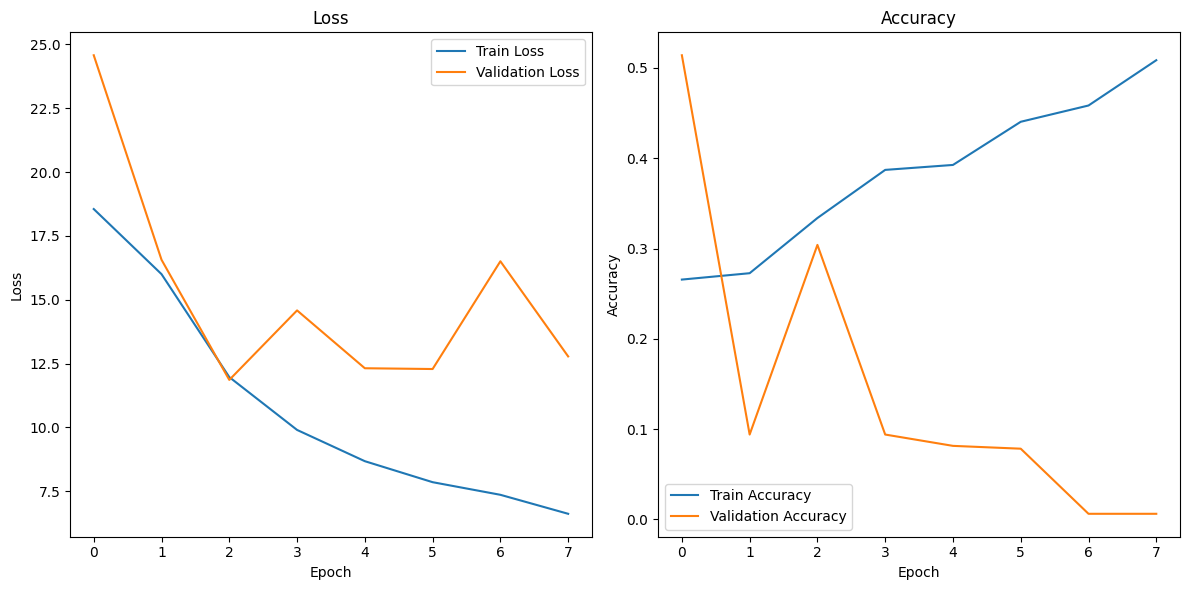

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step


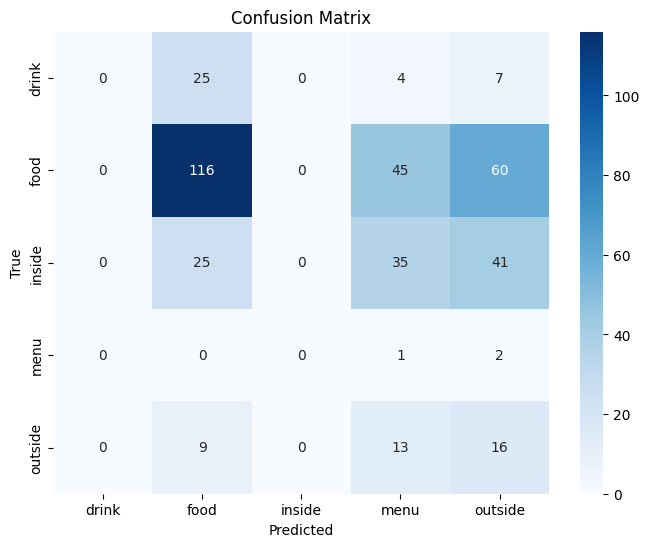

AUC Score: 0.6358

Classification Report:
              precision    recall  f1-score   support

       drink       0.00      0.00      0.00        36
        food       0.66      0.52      0.59       221
      inside       0.00      0.00      0.00       101
        menu       0.01      0.33      0.02         3
     outside       0.13      0.42      0.20        38

    accuracy                           0.33       399
   macro avg       0.16      0.26      0.16       399
weighted avg       0.38      0.33      0.34       399


Starting Round 2 of Empirical Tuning



/home/saraka/tf/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/saraka/tf/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/saraka/tf/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/saraka/tf/lib/python3.12/sit

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - accuracy: 0.2358 - loss: 10.5802 - precision: 0.2319 - recall: 0.1437
Epoch 1: val_loss improved from inf to 14.58126, saving model to save_at_1.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 15s 227ms/step - accuracy: 0.2358 - loss: 10.5937 - precision: 0.2324 - recall: 0.1439 - val_accuracy: 0.2351 - val_loss: 14.5813 - val_precision: 0.2351 - val_recall: 0.2351 - learning_rate: 0.0010
Epoch 2/200
38/40 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2609 - loss: 11.0655 - precision: 0.2583 - recall: 0.1498
Epoch 2: val_loss improved from 14.58126 to 12.29653, saving model to save_at_2.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 5s 117ms/step - accuracy: 0.2610 - loss: 11.0549 - precision: 0.2590 - recall: 0.1505 - val_accuracy: 0.3292 - val_loss: 12.2965 - val_precision: 0.3292 - val_recall: 0.3292 - learning_rate: 0.0010
Epoch 3/200
38/40 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3253 - loss: 9.5274 - precision: 0.3473 - recall: 0.1884
Epoch 3: v

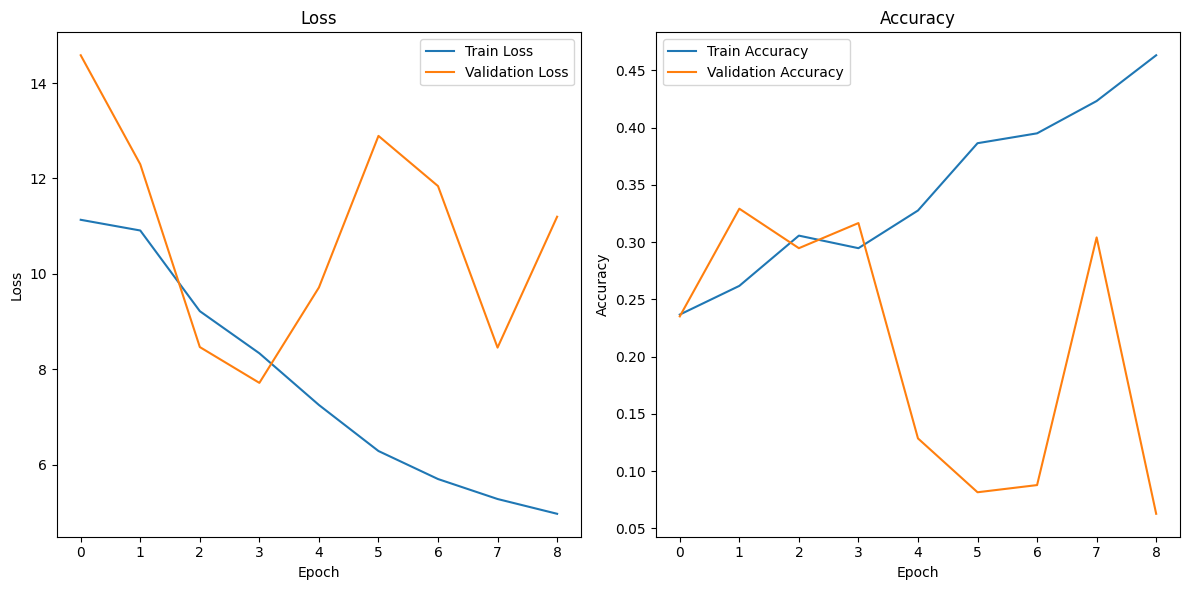

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


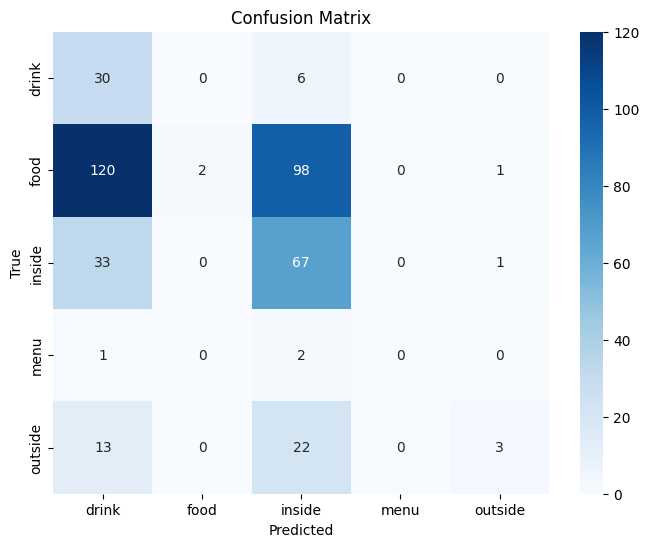

AUC Score: 0.6181

Classification Report:
              precision    recall  f1-score   support

       drink       0.15      0.83      0.26        36
        food       1.00      0.01      0.02       221
      inside       0.34      0.66      0.45       101
        menu       0.00      0.00      0.00         3
     outside       0.60      0.08      0.14        38

    accuracy                           0.26       399
   macro avg       0.42      0.32      0.17       399
weighted avg       0.71      0.26      0.16       399


Starting Round 3 of Empirical Tuning



/home/saraka/tf/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/saraka/tf/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/saraka/tf/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/saraka/tf/lib/python3.12/sit

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.2462 - loss: 4.0111 - precision: 0.2381 - recall: 0.1326
Epoch 1: val_loss improved from inf to 40.89925, saving model to save_at_1.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 17s 228ms/step - accuracy: 0.2461 - loss: 4.0105 - precision: 0.2383 - recall: 0.1327 - val_accuracy: 0.0846 - val_loss: 40.8993 - val_precision: 0.0846 - val_recall: 0.0846 - learning_rate: 0.0010
Epoch 2/200
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3251 - loss: 3.5824 - precision: 0.3760 - recall: 0.2266
Epoch 2: val_loss improved from 40.89925 to 12.23140, saving model to save_at_2.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.3257 - loss: 3.5904 - precision: 0.3759 - recall: 0.2257 - val_accuracy: 0.0815 - val_loss: 12.2314 - val_precision: 0.0818 - val_recall: 0.0815 - learning_rate: 0.0010
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3838 - loss: 3.1635 - precision: 0.4519 - recall: 0.2542
Epoch 3: val_lo

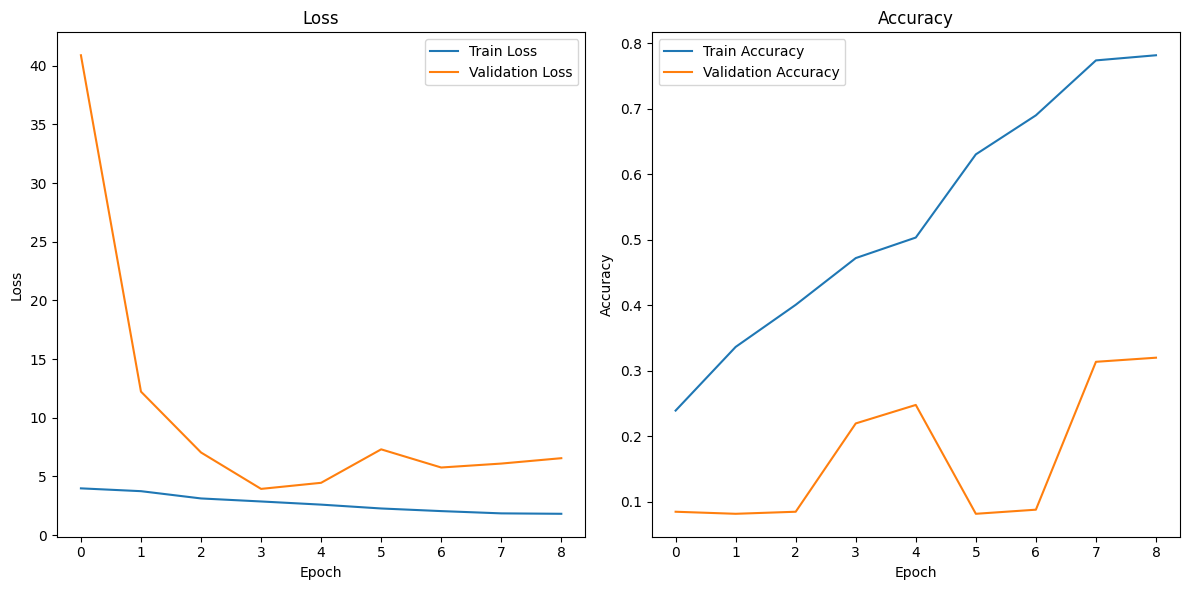

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step


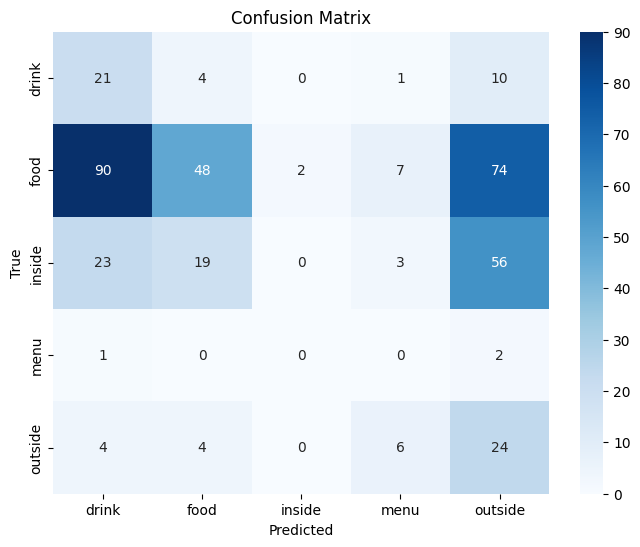

AUC Score: 0.6571

Classification Report:
              precision    recall  f1-score   support

       drink       0.15      0.58      0.24        36
        food       0.64      0.22      0.32       221
      inside       0.00      0.00      0.00       101
        menu       0.00      0.00      0.00         3
     outside       0.14      0.63      0.24        38

    accuracy                           0.23       399
   macro avg       0.19      0.29      0.16       399
weighted avg       0.38      0.23      0.22       399



In [16]:
for round_num, params in enumerate(rounds, start=1):
    print(f"\nStarting Round {round_num} of Empirical Tuning\n")
    input_shape = X_train.shape[1:]
    num_classes = y_categorical.shape[1]
    
    dnn_model = build_and_compile(input_shape, num_classes, l2_reg=params['l2_reg'], dropout_rate=params['dropout_rate'])
    history, dnn_model = train_and_evaluate(dnn_model, X_train, y_train, X_test, y_test)

    # Visualize training history
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Confusion Matrix
    y_pred_probs = dnn_model.predict(X_test)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)
    conf_matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()

    # AUC Score
    auc_score = roc_auc_score(y_test, y_pred_probs, multi_class="ovr")
    print(f"AUC Score: {auc_score:.4f}")

    # Classification Report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=le.classes_))

In [17]:
dnn_model = build_and_compile(input_shape, num_classes, l2_reg=0.001, dropout_rate=0.02)
history, dnn_model = train_and_evaluate(dnn_model, X_train, y_train, X_test, y_test)

/home/saraka/tf/lib/python3.12/site-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.2310 - loss: 4.4451 - precision: 0.2621 - recall: 0.1391
Epoch 1: val_loss improved from inf to 19.66202, saving model to save_at_1.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 16s 190ms/step - accuracy: 0.2311 - loss: 4.4326 - precision: 0.2622 - recall: 0.1386 - val_accuracy: 0.5141 - val_loss: 19.6620 - val_precision: 0.5141 - val_recall: 0.5141 - learning_rate: 0.0010
Epoch 2/200
39/40 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3815 - loss: 3.3770 - precision: 0.4869 - recall: 0.1662
Epoch 2: val_loss improved from 19.66202 to 10.96536, saving model to save_at_2.keras
40/40 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.3814 - loss: 3.3759 - precision: 0.4852 - recall: 0.1665 - val_accuracy: 0.0846 - val_loss: 10.9654 - val_precision: 0.0846 - val_recall: 0.0846 - learning_rate: 0.0010
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.4430 - loss: 3.0417 - precision: 0.5081 - recall: 0.2079
Epoch 3: val_lo

In [18]:
shuffle_idx = np.random.permutation(len(X))
X = X[shuffle_idx]
y_categorical = y_categorical[shuffle_idx]
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
histories = []
cv_metrics = []

In [19]:
for train_idx, val_idx in kfold.split(X, y_categorical):
    print(f'\nTraining Fold #{fold_no}')
    
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y_categorical[train_idx], y_categorical[val_idx]
    
    input_shape = X_train.shape[1:]
    num_classes = y_categorical.shape[1]
    
    dnn_model = build_and_compile(input_shape, num_classes, l2_reg=0.001, dropout_rate=0.3)
    
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
    ]
    
    history = dnn_model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=32,
        class_weight=class_weight_dict,
        callbacks=callbacks,
        verbose=1
    )
    
    histories.append(history)
    val_metrics = dnn_model.evaluate(X_val, y_val, verbose=0)
    cv_metrics.append(val_metrics)
    
    fold_no += 1

final_metrics = np.mean(cv_metrics, axis=0)
print(f"\nCross-Validated Metrics:")
print(f"Loss: {final_metrics[0]:.4f}")
print(f"Accuracy: {final_metrics[1]:.4f}")
print(f"Recall: {final_metrics[2]:.4f}")
print(f"Precision: {final_metrics[3]:.4f}")


Training Fold #1
Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 17s 166ms/step - accuracy: 0.2604 - loss: 3.9330 - precision: 0.2807 - recall: 0.1733 - val_accuracy: 0.4236 - val_loss: 15.7906 - val_precision: 0.4236 - val_recall: 0.4236 - learning_rate: 0.0010
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.2761 - loss: 3.6498 - precision: 0.3071 - recall: 0.1745 - val_accuracy: 0.0902 - val_loss: 12.7883 - val_precision: 0.0902 - val_recall: 0.0902 - learning_rate: 0.0010
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ -1s -11947us/step - accuracy: 0.3327 - loss: 3.4298 - precision: 0.3512 - recall: 0.1918 - val_accuracy: 0.1103 - val_loss: 4.3025 - val_precision: 0.1133 - val_recall: 0.0727 - learning_rate: 0.0010
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.3688 - loss: 3.2178 - precision: 0.4070 - recall: 0.2397 - val_accuracy: 0.1028 - val_loss: 4.1055 - val_precision: 0.0789 - val_recall: 0.0602 - learning_rate: 0.0010
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 